In [1]:
import pandas as pd

import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

import plotly.express as px
import plotly.graph_objects as go
import plotly.figure_factory as ff

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet, LassoCV, RidgeCV, ElasticNetCV
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder

from haversine import haversine, Unit
from sklearn.impute import KNNImputer
import math

import warnings
warnings.filterwarnings("ignore")

In [2]:
### carga datos de dataset en dataframe
file_path= 'uber_fares.csv'

df = pd.read_csv(file_path)

In [3]:
### visualizacion de algunos datos
df.head()

,key,date,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,24238194,2015-05-07 19:52:06.0000003,7.5,2015-05-07 19:52:06 UTC,-73.999817,40.738354,-73.999512,40.723217,1
1,27835199,2009-07-17 20:04:56.0000002,7.7,2009-07-17 20:04:56 UTC,-73.994355,40.728225,-73.994710,40.750325,1
2,44984355,2009-08-24 21:45:00.00000061,12.9,2009-08-24 21:45:00 UTC,-74.005043,40.740770,-73.962565,40.772647,1
3,25894730,2009-06-26 08:22:21.0000001,5.3,2009-06-26 08:22:21 UTC,-73.976124,40.790844,-73.965316,40.803349,3
4,17610152,2014-08-28 17:47:00.000000188,16.0,2014-08-28 17:47:00 UTC,-73.925023,40.744085,-73.973082,40.761247,5


#### Contexto  
El proyecto trata sobre **Uber Inc.**, la compañía de taxis más grande del mundo. En este trabajo, nuestro objetivo es **predecir la tarifa de futuros viajes**.  

Uber brinda servicio a millones de clientes cada día, por lo que gestionar adecuadamente sus datos es clave para desarrollar nuevas estrategias de negocio y obtener mejores resultados.  

### Variables del conjunto de datos  

**Variables explicativas:**  
- **key**: identificador único de cada viaje.  
- **pickup_datetime**: fecha y hora en que se inició el viaje.  
- **passenger_count**: cantidad de pasajeros en el vehículo (dato ingresado por el conductor).  
- **pickup_longitude**: longitud del punto de inicio del viaje.  
- **pickup_latitude**: latitud del punto de inicio del viaje.  
- **dropoff_longitude**: longitud del punto de destino.  
- **dropoff_latitude**: latitud del punto de destino.  

**Variable objetivo (target):**  
- **fare_amount**: costo del viaje en dólares.  

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   key                200000 non-null  int64  
 1   date               200000 non-null  object 
 2   fare_amount        200000 non-null  float64
 3   pickup_datetime    200000 non-null  object 
 4   pickup_longitude   200000 non-null  float64
 5   pickup_latitude    200000 non-null  float64
 6   dropoff_longitude  199999 non-null  float64
 7   dropoff_latitude   199999 non-null  float64
 8   passenger_count    200000 non-null  int64  
dtypes: float64(5), int64(2), object(2)
memory usage: 13.7+ MB


In [5]:
df_limpio = df.copy()

# Dividir datos de entrenamiento y testeo

In [6]:
x = df_limpio.drop('fare_amount', axis=1)
y = df_limpio['fare_amount']
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# Feature Engineering

In [7]:
# Límites geográficos de Nueva York
NY_COORDENADAS = {
    'min_lat': 40.4774,
    'max_lat': 40.9176,
    'min_lon': -74.2591,
    'max_lon': -73.7004
}

## Filtro Geografico
Tomamos el criterio de analizar los viajes que se realizaron dentro de las coordenadas de Nueva York, y tomar como outliers los que se realizaron fuera de esa ubicacion.

In [8]:
# Filtramos los valores por fuera de las coordenadas de NY y completamos con nan los que están fuera
lat_cols = ['pickup_latitude', 'dropoff_latitude']
lon_cols = ['pickup_longitude', 'dropoff_longitude']

# En X_train
for col in lat_cols:
      mask = ~X_train[col].between(NY_COORDENADAS['min_lat'], NY_COORDENADAS['max_lat'])  # máscara para los valores que NO están entre las coordenadas
      X_train.loc[mask, col] = np.nan


for col in lon_cols:
      mask = ~X_train[col].between(NY_COORDENADAS['min_lon'], NY_COORDENADAS['max_lon']) # máscara para los valores que NO están entre las coordenadas
      X_train.loc[mask, col] = np.nan

# En X_test
for col in lat_cols:
      mask = ~X_test[col].between(NY_COORDENADAS['min_lat'], NY_COORDENADAS['max_lat'])  # máscara para los valores que NO están entre las coordenadas
      X_test.loc[mask, col] = np.nan

for col in lon_cols:
      mask = ~X_test[col].between(NY_COORDENADAS['min_lon'], NY_COORDENADAS['max_lon'])  # máscara para los valores que NO están entre las coordenadas
      X_test.loc[mask, col] = np.nan


In [9]:
# Verificamos el tamanio de los conjuntos
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((160000, 8), (160000,), (40000, 8), (40000,))

In [10]:
# Coordenadas de Nueva York, dentro del rango y las completadas con NaN. Dan 160.000 de X_train. Correcto
print(sum(X_train['pickup_latitude'].between(NY_COORDENADAS['min_lat'], NY_COORDENADAS['max_lat'])))
print(sum(X_train['dropoff_latitude'].between(NY_COORDENADAS['min_lat'], NY_COORDENADAS['max_lat'])))
print(sum(X_train['dropoff_longitude'].between(NY_COORDENADAS['min_lon'], NY_COORDENADAS['max_lon'])))
print(sum(X_train['pickup_longitude'].between(NY_COORDENADAS['min_lon'], NY_COORDENADAS['max_lon'])) + sum(X_train['pickup_longitude'].isna()))
print(sum(X_train['dropoff_longitude'].isna()))
print(sum(X_train['pickup_longitude'].isna()))

156738
156726
156711
160000
3289
3284


In [11]:
# Comprobamos la cantidad de observaciones con longitud y latitud = 0
print(sum(X_train['pickup_latitude'] == 0))
print(sum(X_train['pickup_longitude'] == 0))
print(sum(X_train['dropoff_latitude'] == 0))
print(sum(X_train['dropoff_longitude'] == 0))
print(sum((X_train['pickup_longitude'] == 0)& (X_train['dropoff_latitude'] == 0)& (X_train['dropoff_longitude'] == 0) & (X_train['pickup_latitude'] == 0)))

print(sum(y_train == 0))

0
0
0
0
0
5


## Valores faltantes
Al principio decidimos utilizar el escalado robusto, pero los resultados obtenidos para le modelo eran muy pobres (menos de 8%).

Creditos al profe Ivan que nos sugirio usar el escalado estandar.

In [12]:
# ESCALADO STANDARD

##### X_train #####
scaler = StandardScaler()
cols_a_escalar = ['pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude', 'passenger_count']

# Identificamos las filas sin NaN
filas_sin_nan = ~X_train[cols_a_escalar].isna().any(axis=1)
df_sin_nan = X_train.loc[filas_sin_nan, cols_a_escalar]

# Escalamos sólo las filas sin NaN
df_sin_nan_escalado_array = scaler.fit_transform(df_sin_nan)

# Creamos un nuevo DataFrame con los datos escalados, manteniendo el índice original
columnas_escaladas = [col + '_escalada' for col in cols_a_escalar]
df_sin_nan_escalado = pd.DataFrame(df_sin_nan_escalado_array, columns=columnas_escaladas, index=df_sin_nan.index)

# Unimos las nuevas columnas escaladas al df X_train original
X_train[columnas_escaladas] = np.nan

# Rellenamos las columnas nuevas con los valores escalados
X_train.loc[df_sin_nan_escalado.index, columnas_escaladas] = df_sin_nan_escalado.values


##### Lo mismo con X_test #####
filas_sin_nan = ~X_test[cols_a_escalar].isna().any(axis=1)
df_sin_nan = X_test.loc[filas_sin_nan, cols_a_escalar]

df_sin_nan_escalado_array = scaler.transform(df_sin_nan)

columnas_escaladas = [col + '_escalada' for col in cols_a_escalar]
df_sin_nan_escalado = pd.DataFrame(df_sin_nan_escalado_array, columns=columnas_escaladas, index=df_sin_nan.index)

X_test[columnas_escaladas] = np.nan

X_test.loc[df_sin_nan_escalado.index, columnas_escaladas] = df_sin_nan_escalado.values

In [13]:
# Verificamos el tamanio de los conjuntos
X_train.shape, y_train.shape

((160000, 13), (160000,))

## Imputacion

In [14]:
# Imputamos las COORDENADAS con KNN
imputer = KNNImputer(n_neighbors=5)

cols = ['pickup_longitude_escalada','pickup_latitude_escalada','dropoff_latitude_escalada','dropoff_longitude_escalada']

X_train[cols] = imputer.fit_transform(X_train[cols])
X_test[cols] = imputer.transform(X_test[cols])

In [15]:
# Verificamos de nuevo el tamanio de los conjuntos
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((160000, 13), (160000,), (40000, 13), (40000,))

In [16]:
# DESESCALADO
col_escaladas = ['pickup_longitude_escalada', 'pickup_latitude_escalada', 'dropoff_longitude_escalada', 'dropoff_latitude_escalada', 'passenger_count_escalada']


##### X_train #####
# Desescalamos los datos de TODAS las columnas
datos_desescalados_array = scaler.inverse_transform(X_train[col_escaladas].values)

# Creamos una lista con los nombres de las columnas nuevas con el sufijo '_desescalada'
col_desescaladas = [col.replace('_escalada', '_desescalada') for col in col_escaladas]

# Asignamos los valores desescalados a las columnas nuevas en X_train
X_train[col_desescaladas] = datos_desescalados_array


##### Lo mismo con X_test #####
datos_desescalados_array = scaler.inverse_transform(X_test[col_escaladas].values)

col_desescaladas = [col.replace('_escalada', '_desescalada') for col in col_escaladas]

X_test[col_desescaladas] = datos_desescalados_array

In [17]:
# Verificamos de nuevo el tamanio de los conjuntos
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((160000, 18), (160000,), (40000, 18), (40000,))

## Calculo de las distancias recorridas en km

In [18]:
##### X_train #####
X_train['distancia_km'] = X_train.apply(lambda row: haversine(
  (row['pickup_latitude_desescalada'], row['pickup_longitude_desescalada']),
  (row['dropoff_latitude_desescalada'], row['dropoff_longitude_desescalada'])
), axis=1)

X_train['distancia_km'].describe()

count    160000.000000
mean          3.237380
std           3.545887
min           0.000000
25%           1.206936
50%           2.111059
75%           3.841573
max          35.341909
Name: distancia_km, dtype: float64

In [19]:
##### X_test #####
X_test['distancia_km'] = X_test.apply(lambda row: haversine(
    (row['pickup_latitude_desescalada'], row['pickup_longitude_desescalada']),
    (row['dropoff_latitude_desescalada'], row['dropoff_longitude_desescalada'])
), axis=1)

X_test['distancia_km'].describe()

count    40000.000000
mean         3.226050
std          3.557582
min          0.000000
25%          1.192721
50%          2.086576
75%          3.834362
max         33.254651
Name: distancia_km, dtype: float64

In [20]:
# Verificamos de nuevo el tamanio de los conjuntos
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((160000, 19), (160000,), (40000, 19), (40000,))

In [21]:
# Verificamos el tamanio de los conjuntos
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((160000, 19), (160000,), (40000, 19), (40000,))

## Tratamiento de las fechas
### Dia de la semana

In [22]:
## Primero convertimos a datetime y luego conseguimos el dia de la semana (numerico)

##### X_train #####
X_train['day_week_num'] = pd.to_datetime(X_train['date'], utc=True)
X_train['day_week_num'] = X_train['day_week_num'].dt.dayofweek
X_train['day_week_num']

##### X_test #####
X_test['day_week_num'] = pd.to_datetime(X_test['date'], utc=True)
X_test['day_week_num'] = X_test['day_week_num'].dt.dayofweek

# Despues usamos ese numero que representa el dia de la semana para la Codificacion Ciclica de los dias
def circular_encoding(X_train, column, n_categorias):
    sin_col = f"{column}_sin"
    cos_col = f"{column}_cos"
    X_train[sin_col] = np.sin((2 * np.pi * (X_train[column]))/ n_categorias)
    X_train[cos_col] = np.cos((2 * np.pi * (X_train[column])) / n_categorias)
    return X_train

X_train = circular_encoding(X_train, 'day_week_num', 7)

X_test = circular_encoding(X_test, 'day_week_num', 7)

In [23]:
print(X_train['day_week_num_sin'])

153248    0.433884
67802     0.974928
148889   -0.781831
103093   -0.974928
104681   -0.781831
            ...   
119879    0.433884
103694   -0.781831
131932   -0.974928
146867    0.781831
121958   -0.974928
Name: day_week_num_sin, Length: 160000, dtype: float64


In [24]:
##### X_train #####
X_train['fecha_hora'] = pd.to_datetime(X_train['date'].str.replace(' UTC', ''), utc=True) # convertirmos a datetime

X_train['hora'] = X_train['fecha_hora'].dt.hour # extraemos la hora de la fecha general

etiquetas = ['Madrugada', 'Mañana', 'Tarde', 'Noche']# O LO HACEMOS NUMERICO PARA DESPUÉS PODER HACER CALCULOS DE COSTO + DÍA DE LA SEMANA EN LA FUNCIÓN DE REGRESIÓN?

bins = [0, 6, 12, 18, 24]

X_train['period_of_the_day'] = pd.cut(X_train['hora'], bins=bins, labels=etiquetas, right=False, include_lowest=True) # genera una columna nueva con las variables categóricas

X_train['period_of_the_day']

##### X_test #####
X_test['fecha_hora'] = pd.to_datetime(X_test['date'].str.replace(' UTC', ''), utc=True)

X_test['hora'] = X_test['fecha_hora'].dt.hour

etiquetas = ['Madrugada', 'Mañana', 'Tarde', 'Noche']
bins = [0, 6, 12, 18, 24]

X_test['period_of_the_day'] = pd.cut(X_test['hora'], bins=bins, labels=etiquetas, right=False, include_lowest=True)

In [25]:
# Circular enconding para el momento del día
X_train = circular_encoding(X_train, 'hora', 24)

X_test = circular_encoding(X_test, 'hora', 24)

X_train['hora_cos']

153248    0.707107
67802     0.866025
148889   -0.500000
103093    0.965926
104681   -0.965926
            ...   
119879   -0.258819
103694    0.258819
131932   -0.965926
146867    0.258819
121958   -0.707107
Name: hora_cos, Length: 160000, dtype: float64

In [26]:
# Cantidad de pasajeros mayores a 10
##### X_train #####
print(f"\nCantidad de pasajeros mayores a 10 ANTES del filtro: {(X_train['passenger_count'] > 10).sum()}")

# Crea la máscara para pasajeros <= 10
valid_passengers_mask = X_train['passenger_count'] <= 10

# Aplica el filtro a X_train
X_train = X_train[valid_passengers_mask]

# Y APLICA EL MISMO FILTRO A Y_TRAIN USANDO LA MISMA MÁSCARA
y_train = y_train[valid_passengers_mask]


##### X_train #####
# Gastos menores a 0 dolares y_train
print(f"\nCantidad de gastos menores a 0 ANTES del filtro: {(y_train < 0).sum()}")

# Crea la máscara para gastos mayores o iguales a 0
valid_fare_amount_mask = y_train >= 0

# Aplica el filtro a y_train
y_train = y_train[valid_fare_amount_mask]

# Y APLICA EL MISMO FILTRO A X_TRAIN USANDO LA MISMA MÁSCARA
X_train = X_train[valid_fare_amount_mask]

# x_test
valid_fare_amount_mask = y_test >= 0
y_test = y_test[valid_fare_amount_mask]
X_test = X_test[valid_fare_amount_mask]


Cantidad de pasajeros mayores a 10 ANTES del filtro: 1

Cantidad de gastos menores a 0 ANTES del filtro: 14


In [27]:
# Verificamos el tamanio de los conjuntos
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((159985, 27), (159985,), (39997, 27), (39997,))

## Distribuciones

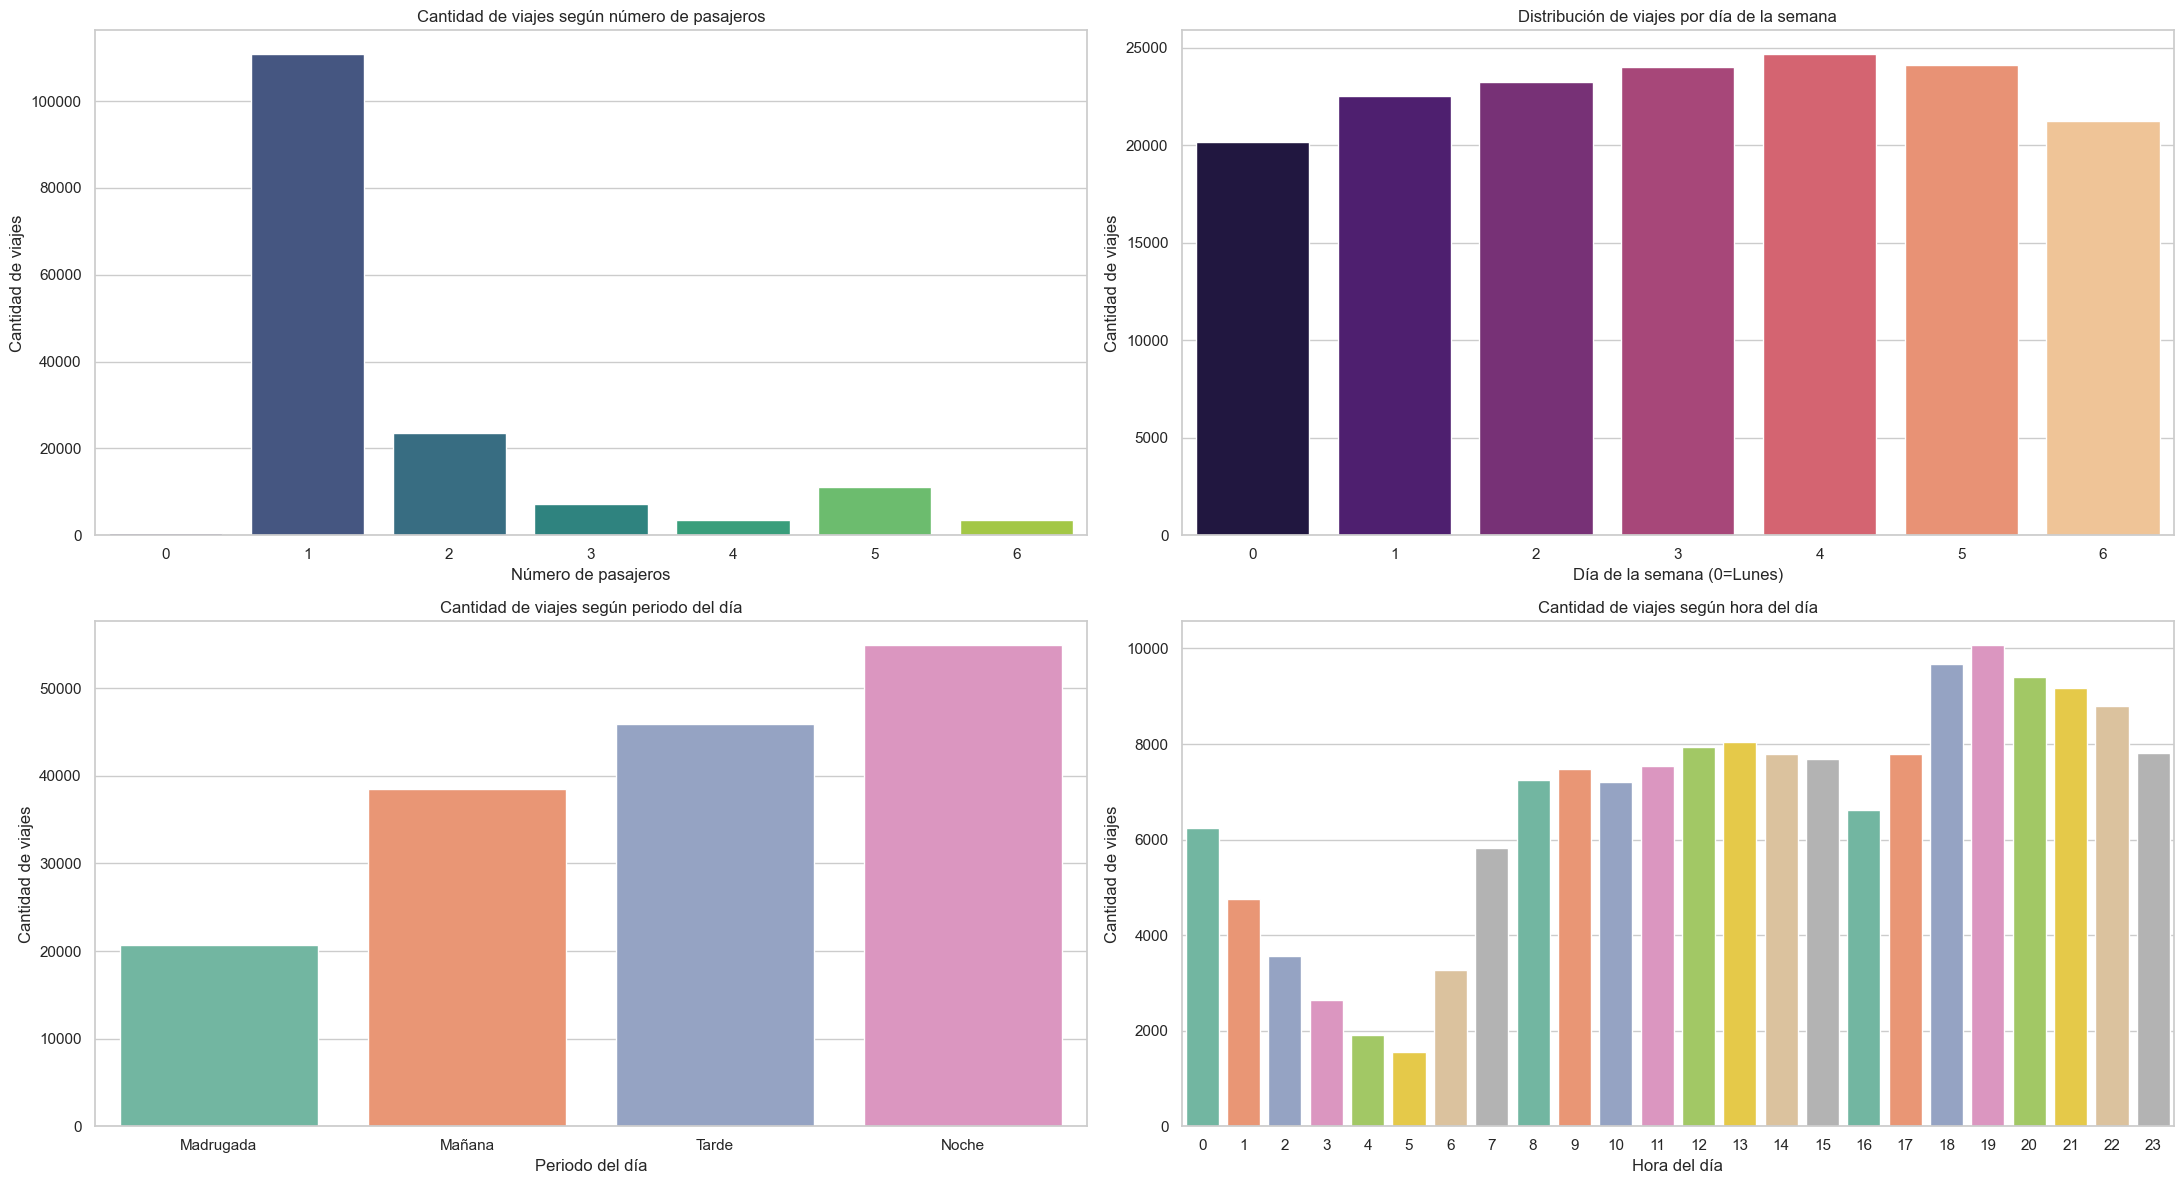

In [28]:
sns.set(style="whitegrid")

fig, axes = plt.subplots(2, 2, figsize=(22, 12))

# Conteo de viajes por cantidad de pasajeros
sns.countplot(data=X_train, x="passenger_count", ax=axes[0,0], palette="viridis")
axes[0,0].set_title("Cantidad de viajes según número de pasajeros")
axes[0,0].set_xlabel("Número de pasajeros")
axes[0,0].set_ylabel("Cantidad de viajes")

# Conteo de viajes por día de la semana
order_days = [0, 1, 2, 3, 4, 5, 6]  # Lunes=0 ... Domingo=6
sns.countplot(data=X_train, x="day_week_num", order=order_days, ax=axes[0,1], palette="magma")
axes[0,1].set_title("Distribución de viajes por día de la semana")
axes[0,1].set_xlabel("Día de la semana (0=Lunes)")
axes[0,1].set_ylabel("Cantidad de viajes")

# Conteo de viajes por franja horaria del día
sns.countplot(
    data=X_train,
    x="period_of_the_day",
    order=["Madrugada", "Mañana", "Tarde", "Noche"],
    ax=axes[1,0],
    palette="Set2"
)
axes[1,0].set_title("Cantidad de viajes según periodo del día")
axes[1,0].set_xlabel("Periodo del día")
axes[1,0].set_ylabel("Cantidad de viajes")

# Conteo de viajes por franja horaria del día
sns.countplot(
    data=X_train,
    x="hora",
    ax=axes[1,1],
    palette="Set2"
)
axes[1,1].set_title("Cantidad de viajes según hora del día")
axes[1,1].set_xlabel("Hora del día")
axes[1,1].set_ylabel("Cantidad de viajes")


plt.tight_layout()
plt.show()

Obervamos que:
- La gran mayoria de los viajes fueron realizados con un unico pasajero.
- La mayor cantidad de viajes se realizan durante los ultimos 3 dias habiles, con pico el viernes.
- La cantidad de viajes asciente desde la madrugada (5am) hasta la noche, y vuelve a caer desde las 7pm hasta las 5am.

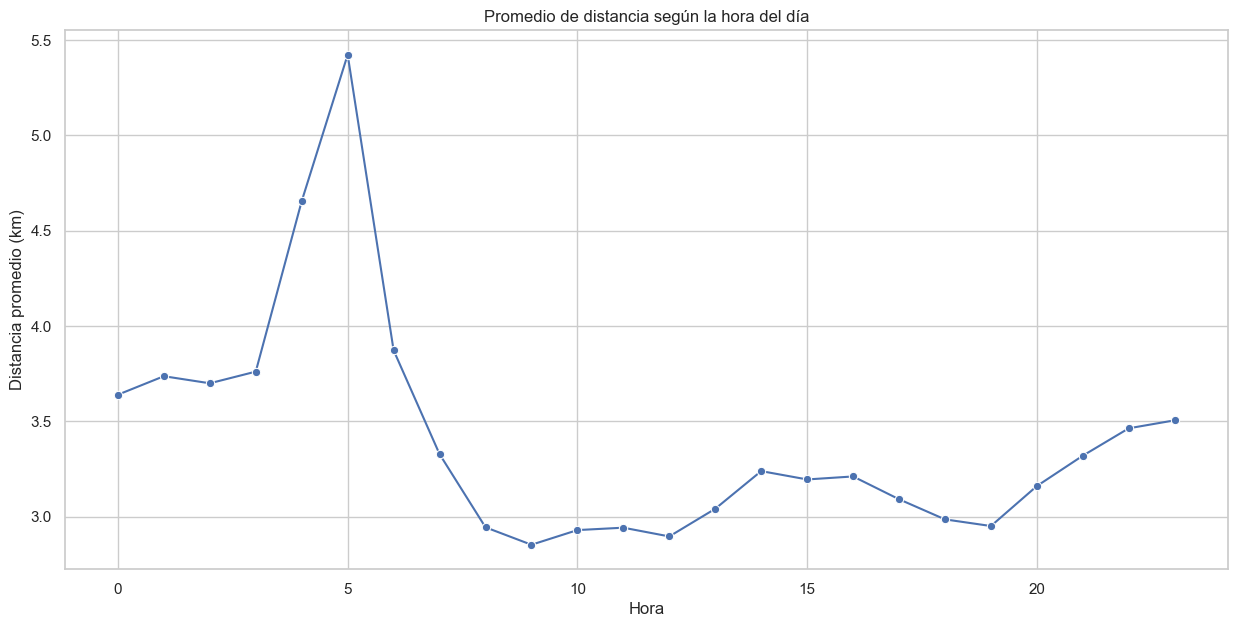

In [29]:
# Promedio de distancia según hora del día

plt.figure(figsize=(15,7))
sns.lineplot(data=X_train, x="hora", y="distancia_km", estimator="mean", ci=None, marker="o")
plt.title("Promedio de distancia según la hora del día")
plt.xlabel("Hora")
plt.ylabel("Distancia promedio (km)")
plt.show()


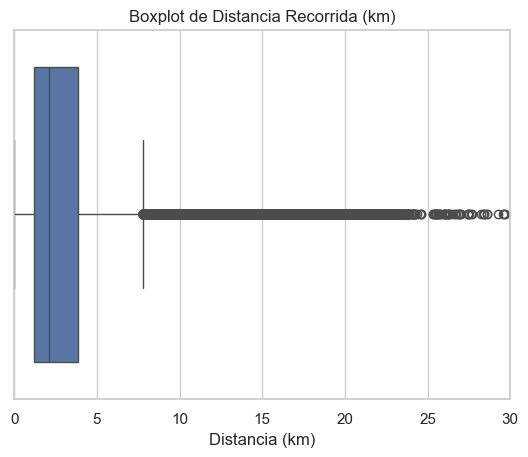

In [30]:
# Boxplot distancia
sns.boxplot(x=X_train['distancia_km'])
plt.title("Boxplot de Distancia Recorrida (km)")
plt.xlabel("Distancia (km)")
plt.xlim(0, 30)
plt.show()

Observamos que:
- Los viajes mas largos, en promedio, se realizan a las 5am, a pesar de ser el horario en el que menos viajes se realizan.
- La mayoria de los viajes tienen una distancia menor a 3.25km.

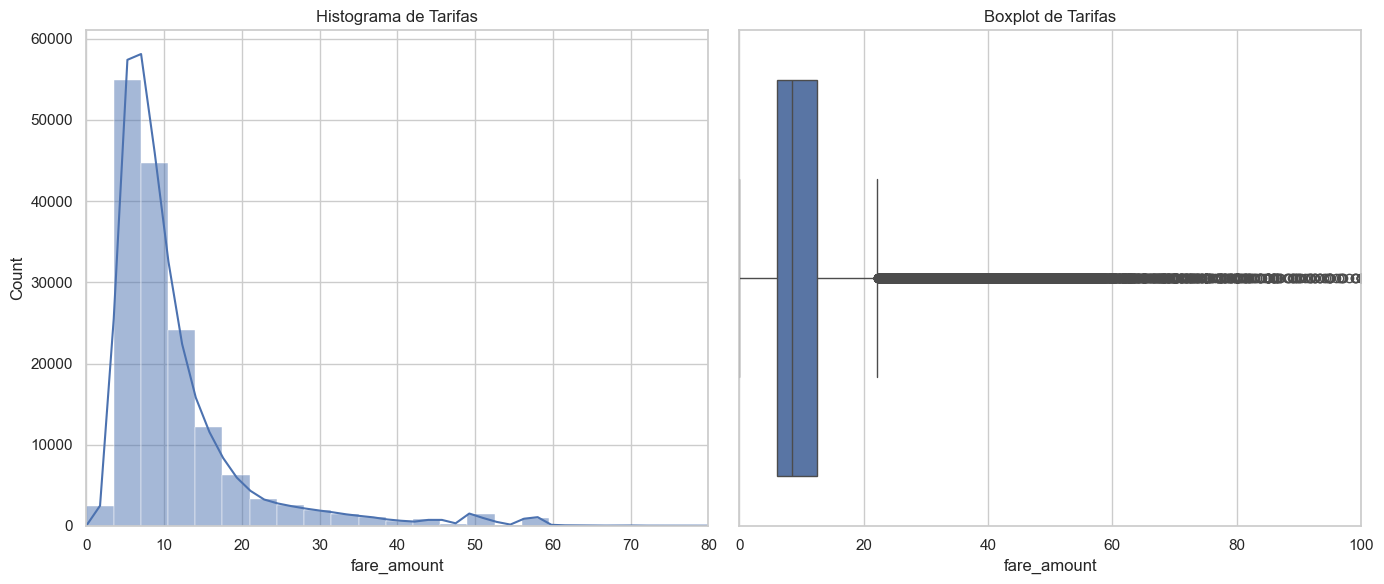

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Histograma de tarifas
sns.histplot(y_train, bins=100, kde=True, ax=axes[0])
axes[0].set_xlim(0, 80)  # límitamos para ver mejor la zona central
axes[0].set_title("Histograma de Tarifas")

# Boxplot de tarifas
sns.boxplot(x=y_train, ax=axes[1])
axes[1].set_xlim(0, 100)
axes[1].set_title("Boxplot de Tarifas")

plt.tight_layout()
plt.show()

Se puede apreciar que la mayoria de los viajes son de los mas baratos, lo que se condice con los graficos anteriores, en el que predominan los viajes con distancias cortas.

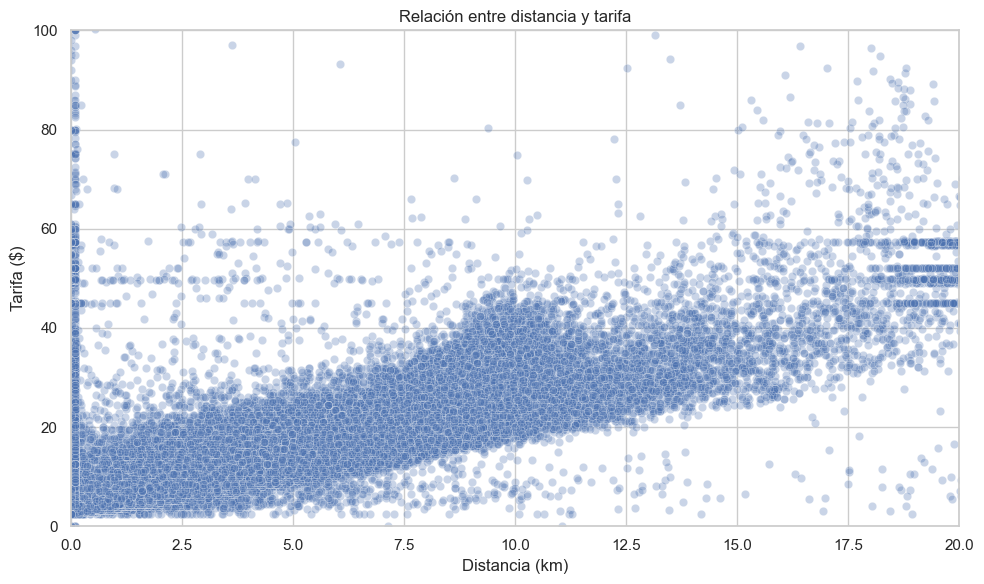

In [32]:
# Scatterplot entre distancia y tarifa
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_train["distancia_km"], y=y_train, alpha=0.3)
plt.xlim(0, 20)   # Limitamos a 20 km para evitar outliers extremos
plt.ylim(0, 100)  # Limitamos a 100 dólares para evitar outliers extremos
plt.title("Relación entre distancia y tarifa")
plt.xlabel("Distancia (km)")
plt.ylabel("Tarifa ($)")
plt.tight_layout()
plt.show()

Vemos que hay outliers de viajes realizados con una tarifa muy alta y una distancia muy corta, verificamos la cantidad.

In [33]:
print(sum((y_train > 40) & (X_train['distancia_km'] < 0.5)))

486


In [34]:

condicion_excluir = (y_train > 40) & (X_train['distancia_km'] < 0.5)

mediana_menores_20 = y_train.loc[~condicion_excluir & (y_train < 20)].median()

condicion_imputar = (y_train > 40) & (X_train['distancia_km'] < 0.5)

y_train.loc[condicion_imputar] = mediana_menores_20

In [35]:
# truncamiento de los outlier relación tarifa - distancia

print(sum((data_combined['target'] >40 )& (data_combined['distancia_km'] < 0.5)))

condicion_excluir = (data_combined['target'] > 40) & (data_combined['distancia_km'] < 0.5)

mediana_menores_20 = data_combined.loc[~condicion_excluir & (data_combined['target'] < 20), 'target'].median()

condicion_imputar = (data_combined['target'] > 40) & (data_combined['distancia_km'] < 0.5)

# Asigna la mediana calculada a la columna 'target' menores a 20 (distancia 0.5) solo en las filas que cumplen la condición de imputación
data_combined.loc[condicion_imputar, 'target'] = mediana_menores_20

NameError: name 'data_combined' is not defined

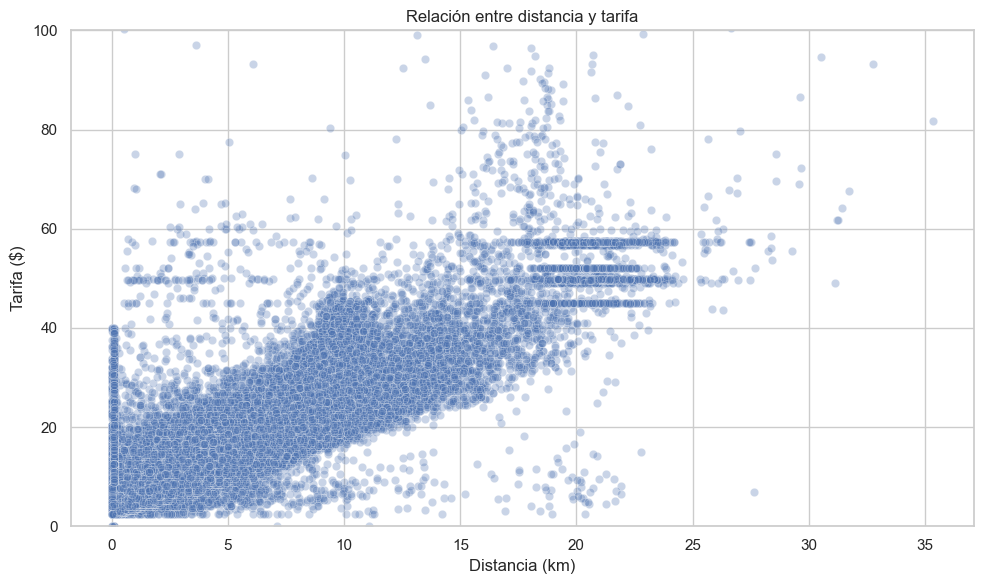

In [ ]:
# Relación entre distancia y tarifa (dispersión)
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_train["distancia_km"], y=y_train, alpha=0.3)
# plt.xlim(0, 20)   # Limitar a 20 km para evitar outliers extremos
plt.ylim(0, 100)  # Limitar a 100 dólares para evitar outliers extremos
plt.title("Relación entre distancia y tarifa")
plt.xlabel("Distancia (km)")
plt.ylabel("Tarifa ($)")
plt.tight_layout()
plt.show()

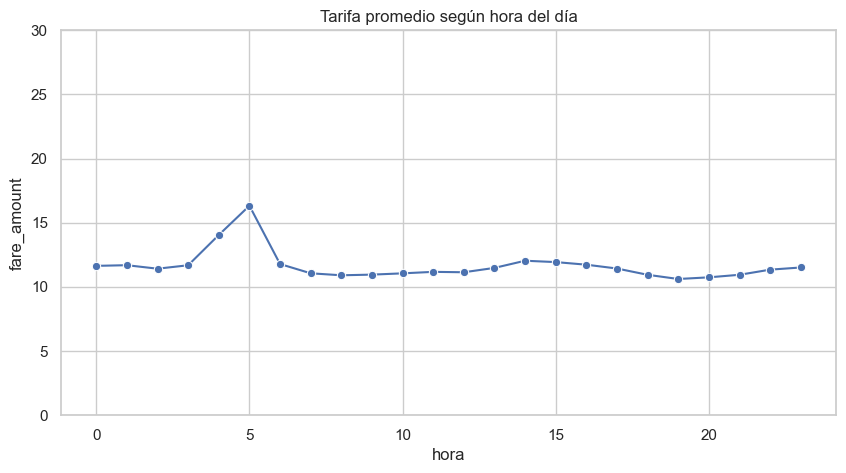

In [ ]:
# Fare por hora del día

plt.figure(figsize=(10,5))
sns.lineplot(x=X_train["hora"], y=y_train, estimator="mean", errorbar=None, marker="o")
plt.ylim(0, 30)
plt.title("Tarifa promedio según hora del día")
plt.show()

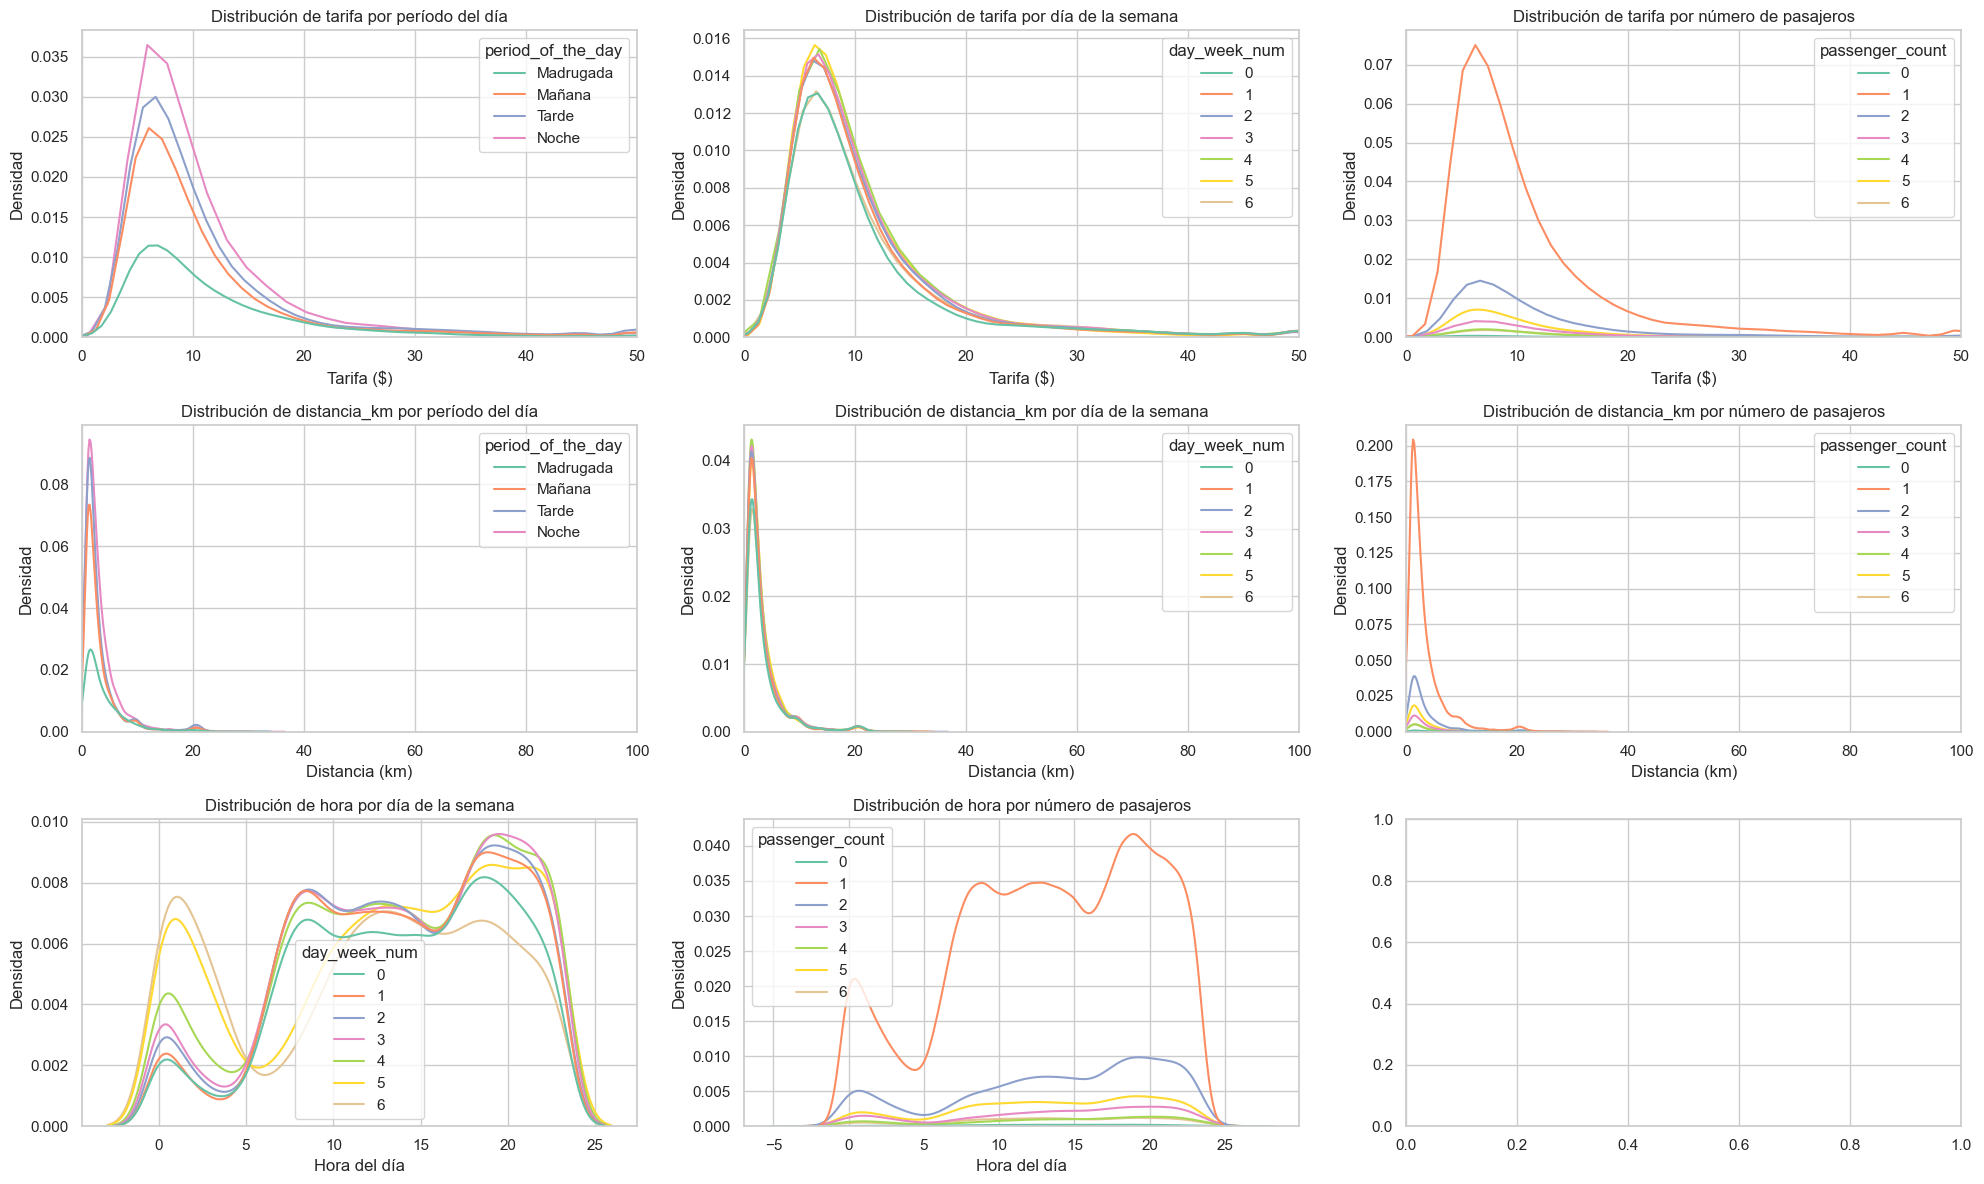

In [ ]:
fig, ((ax1, ax2, ax3) ,(ax4, ax5, ax6), (ax7, ax8, ax9)) = plt.subplots(nrows=3, ncols=3, figsize=(20, 12))

# Combinar X_train y y_train para los gráficos de target
data_combined = X_train.copy()
data_combined['target'] = y_train

# Gráfico 1: Distribución de la variable objetivo por período del día
sns.kdeplot(data=data_combined, x='target', hue='period_of_the_day', palette='Set2', ax=ax1)
ax1.set_xlim(0, 50)
ax1.set_title("Distribución de tarifa por período del día")
ax1.set_xlabel("Tarifa ($)")
ax1.set_ylabel("Densidad")

# Gráfico 2: Distribución de la variable objetivo por día de la semana
sns.kdeplot(data=data_combined, x='target', hue='day_week_num', palette='Set2', ax=ax2)
ax2.set_xlim(0, 50)
ax2.set_title("Distribución de tarifa por día de la semana")
ax2.set_xlabel("Tarifa ($)")
ax2.set_ylabel("Densidad")

# Gráfico 3: Distribución de la variable objetivo por número de pasajeros
sns.kdeplot(data=data_combined, x='target', hue='passenger_count', palette='Set2', ax=ax3)
ax3.set_xlim(0, 50)
ax3.set_title("Distribución de tarifa por número de pasajeros")
ax3.set_xlabel("Tarifa ($)")
ax3.set_ylabel("Densidad")

# Gráfico 4: Distribución de distancia_km por período del día
sns.kdeplot(data=X_train, x='distancia_km', hue='period_of_the_day', palette='Set2', ax=ax4)
ax4.set_xlim(0, 100)
ax4.set_title("Distribución de distancia_km por período del día")
ax4.set_xlabel("Distancia (km)")
ax4.set_ylabel("Densidad")

# Gráfico 5: Distribución de distancia_km por día de la semana
sns.kdeplot(data=X_train, x='distancia_km', hue='day_week_num', palette='Set2', ax=ax5)
ax5.set_xlim(0, 100)
ax5.set_title("Distribución de distancia_km por día de la semana")
ax5.set_xlabel("Distancia (km)")
ax5.set_ylabel("Densidad")

# Gráfico 6: Distribución de distancia_km por número de pasajeros
sns.kdeplot(data=X_train, x='distancia_km', hue='passenger_count', palette='Set2', ax=ax6)
ax6.set_xlim(0, 100)
ax6.set_title("Distribución de distancia_km por número de pasajeros")
ax6.set_xlabel("Distancia (km)")
ax6.set_ylabel("Densidad")

# Gráfico 7: Distribución de hora por día de la semana
sns.kdeplot(data=X_train, x='hora', hue='day_week_num', palette='Set2', ax=ax7)
ax7.set_title("Distribución de hora por día de la semana")
ax7.set_xlabel("Hora del día")
ax7.set_ylabel("Densidad")

# Gráfico 8: Distribución de hora por número de pasajeros
sns.kdeplot(data=X_train, x='hora', hue='passenger_count', palette='Set2', ax=ax8)
ax8.set_title("Distribución de hora por número de pasajeros")
ax8.set_xlabel("Hora del día")
ax8.set_ylabel("Densidad")

plt.tight_layout()
plt.show()

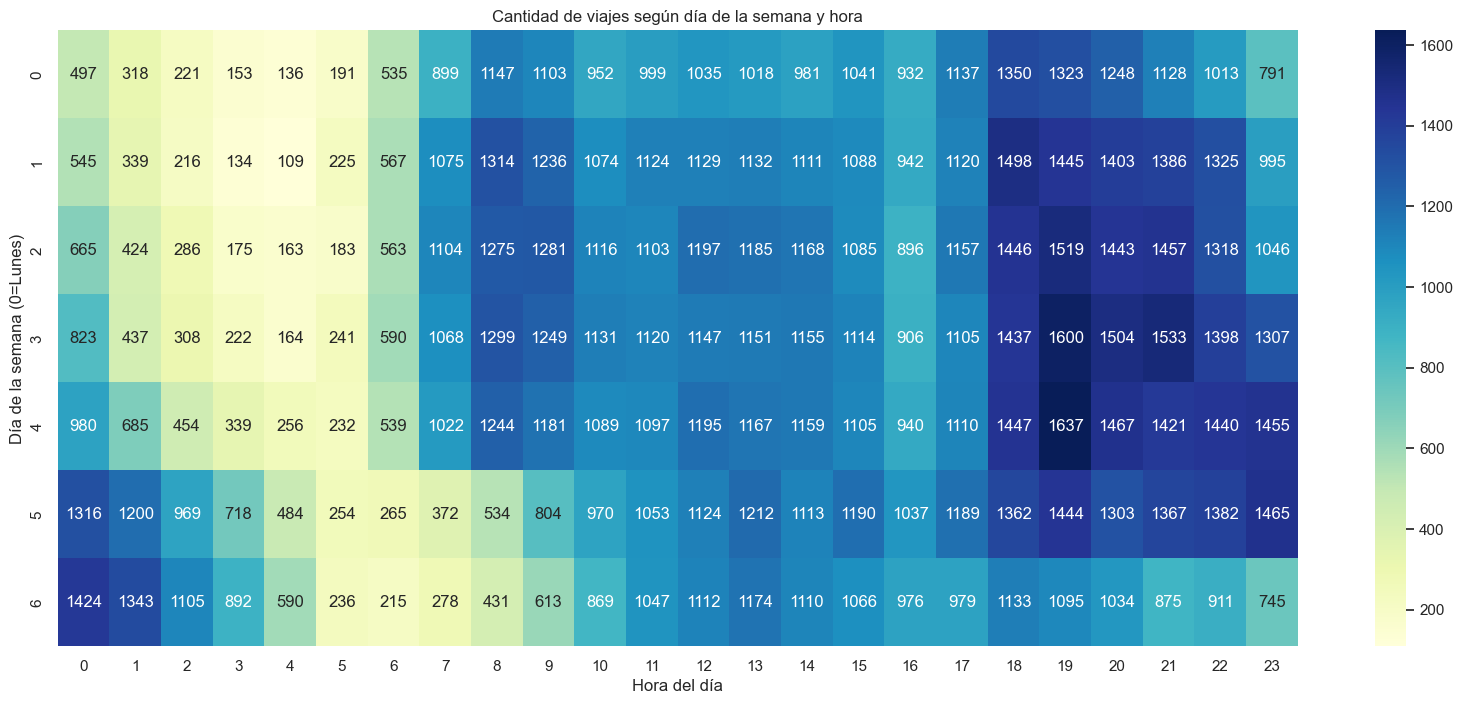

In [ ]:
# Heatmap hora vs día de la semana

pivot_data = X_train.groupby(['day_week_num','hora']).size().unstack(fill_value=0)
plt.figure(figsize=(20,8))
sns.heatmap(pivot_data, cmap="YlGnBu", annot=True, fmt=".0f")
plt.title("Cantidad de viajes según día de la semana y hora")
plt.xlabel("Hora del día")
plt.ylabel("Día de la semana (0=Lunes)")
plt.show()

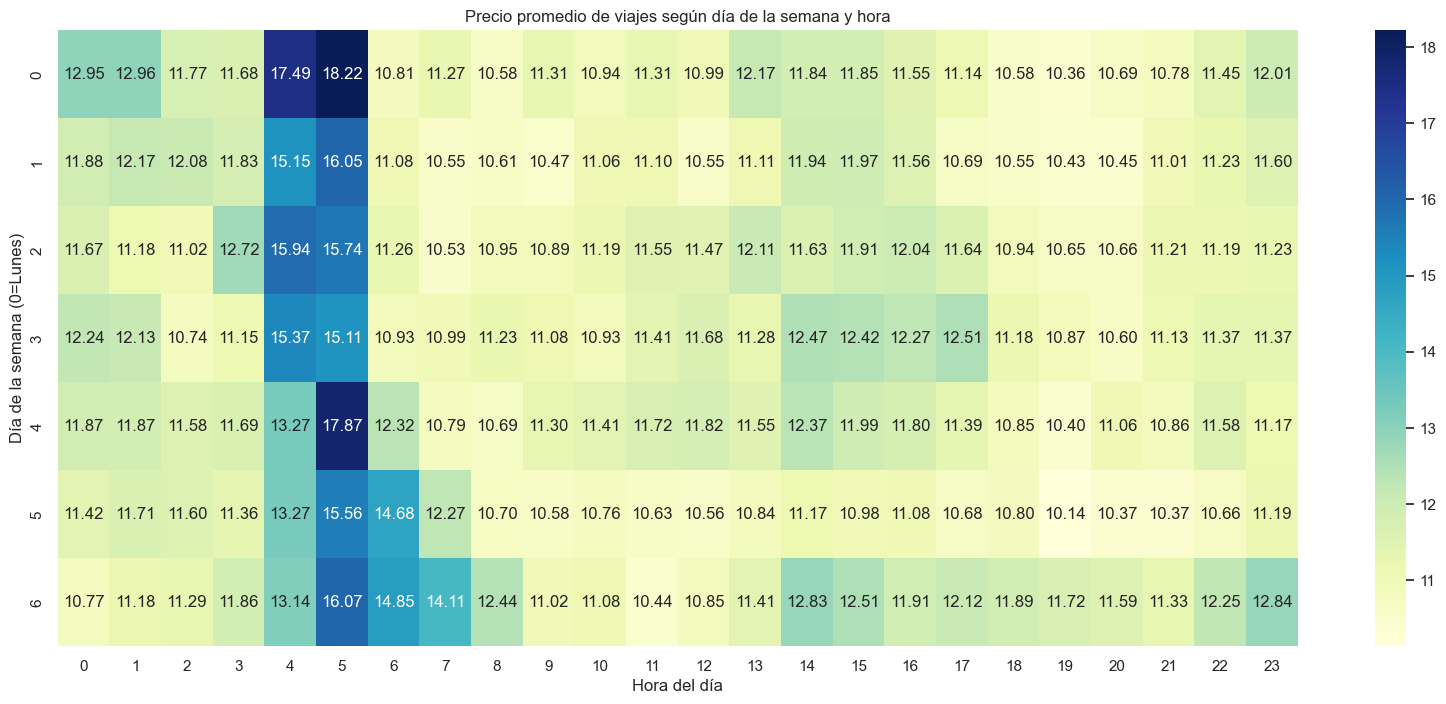

In [ ]:
# Heatmap precio promedio vs día de la semana y hora

# Combinar X_train y y_train
data_combined = X_train[['day_week_num', 'hora']].copy()
data_combined['target'] = y_train

# Agrupar por día de la semana y hora, y calcular el precio promedio
pivot_data = data_combined.groupby(['day_week_num', 'hora'])['target'].mean().unstack(fill_value=0)

plt.figure(figsize=(20, 8))
sns.heatmap(pivot_data, cmap="YlGnBu", annot=True, fmt=".2f")
plt.title("Precio promedio de viajes según día de la semana y hora")
plt.xlabel("Hora del día")
plt.ylabel("Día de la semana (0=Lunes)")
plt.show()

## Correlaciones

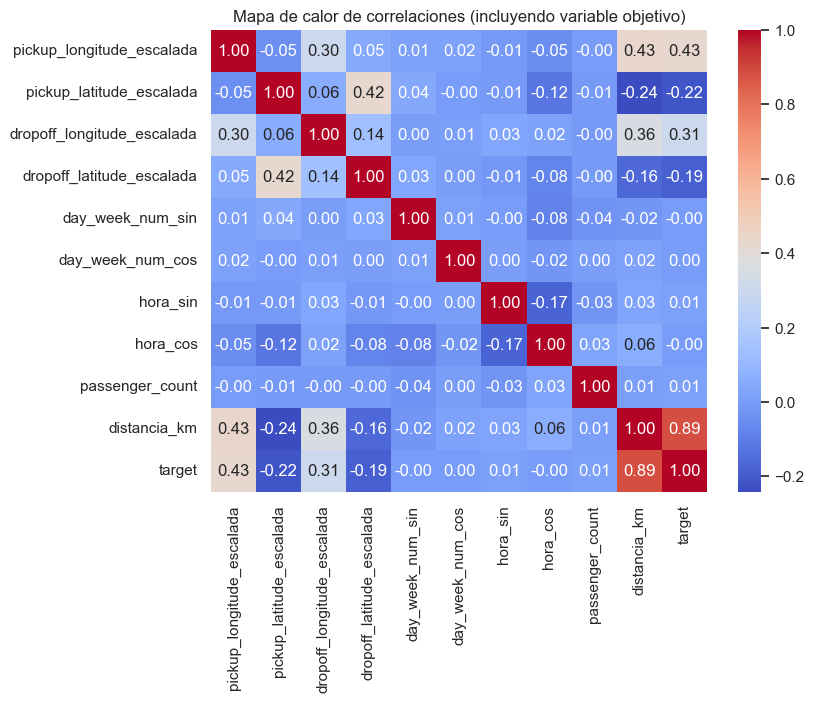

In [ ]:
# Mapa de correlaciones incluyendo variable objetivo

data_combined = X_train[[    'pickup_longitude_escalada',
    'pickup_latitude_escalada',
    'dropoff_longitude_escalada',
    'dropoff_latitude_escalada',
    'day_week_num_sin',
    'day_week_num_cos',
    'hora_sin',
    'hora_cos',
    'passenger_count',
    'distancia_km']].copy()
data_combined['target'] = y_train

corr = data_combined.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Mapa de calor de correlaciones (incluyendo variable objetivo)")
plt.show()

Vemos una correlacion muy alta entre la distancia del viaje y el precio

In [ ]:
# truncamiento de los outlier relación tarifa - distancia

print(sum((data_combined['target'] >40 )& (data_combined['distancia_km'] < 0.5)))

condicion_excluir = (data_combined['target'] > 40) & (data_combined['distancia_km'] < 0.5)

mediana_menores_20 = data_combined.loc[~condicion_excluir & (data_combined['target'] < 20), 'target'].median()

condicion_imputar = (data_combined['target'] > 40) & (data_combined['distancia_km'] < 0.5)

# Asigna la mediana calculada a la columna 'target' menores a 20 (distancia 0.5) solo en las filas que cumplen la condición de imputación
data_combined.loc[condicion_imputar, 'target'] = mediana_menores_20

0


In [ ]:
columnas_escaladas_especificas = [
    'pickup_longitude_desescalada',
    'pickup_latitude_desescalada',
    'dropoff_longitude_desescalada',
    'dropoff_latitude_desescalada',
    'day_week_num_sin',
    'day_week_num_cos',
    'hora_sin',
    'hora_cos',
    'passenger_count',
    'distancia_km'
]

columnas_existentes = [col for col in columnas_escaladas_especificas if col in X_train.columns]

X_train_scaled = X_train[columnas_existentes].copy()

X_test_scaled = X_test[columnas_existentes].copy()

In [ ]:
X_train_scaled.head()

,pickup_longitude_desescalada,pickup_latitude_desescalada,dropoff_longitude_desescalada,dropoff_latitude_desescalada,day_week_num_sin,day_week_num_cos,hora_sin,hora_cos,passenger_count,distancia_km
153248,-73.978585,40.748388,-73.976913,40.784958,0.433884,-0.900969,-0.707107,0.707107,1,4.068841
67802,-73.978198,40.752533,-73.909752,40.874372,0.974928,-0.222521,-0.500000,0.866025,1,14.721602
148889,-73.994242,40.751227,-73.999432,40.762037,-0.781831,0.623490,0.866025,-0.500000,1,1.279042
103093,-73.951705,40.778330,-73.956050,40.777560,-0.974928,-0.222521,-0.258819,0.965926,2,0.375743
104681,-73.989120,40.736932,-73.782890,40.643947,-0.781831,0.623490,-0.258819,-0.965926,1,20.229724


In [ ]:
X_test_scaled.head()

,pickup_longitude_desescalada,pickup_latitude_desescalada,dropoff_longitude_desescalada,dropoff_latitude_desescalada,day_week_num_sin,day_week_num_cos,hora_sin,hora_cos,passenger_count,distancia_km
119737,-74.000458,40.723990,-73.989682,40.725797,0.000000,1.000000,-0.258819,9.659258e-01,1,0.930050
72272,-73.975551,40.750772,-73.974627,40.751088,-0.781831,0.623490,-0.707107,7.071068e-01,5,0.085432
158154,-73.955315,40.779068,-73.970558,40.764650,0.433884,-0.900969,-1.000000,-1.836970e-16,5,2.053762
65426,-73.870920,40.773705,-73.964346,40.797100,0.974928,-0.222521,-0.866025,5.000000e-01,3,8.284795
30074,-73.992195,40.748958,-73.987078,40.743065,0.000000,1.000000,0.866025,-5.000000e-01,1,0.784349


In [ ]:
# Columnas a escalar
cols_coordenadas = ['pickup_longitude_desescalada', 'pickup_latitude_desescalada', 'dropoff_longitude_desescalada', 'dropoff_latitude_desescalada','distancia_km']

# Creamos un nuevo scaler para las coordenadas
scaler_coordenadas = StandardScaler()

# Escalamos las columnas en X_train_scaled
X_train_scaled[cols_coordenadas] = scaler_coordenadas.fit_transform(X_train_scaled[cols_coordenadas])

# Escalamos las columnas en X_test_scaled usando el mismo scaler
X_test_scaled[cols_coordenadas] = scaler_coordenadas.transform(X_test_scaled[cols_coordenadas])

In [ ]:
X_train_scaled.head()

,pickup_longitude_desescalada,pickup_latitude_desescalada,dropoff_longitude_desescalada,dropoff_latitude_desescalada,day_week_num_sin,day_week_num_cos,hora_sin,hora_cos,passenger_count,distancia_km
153248,-0.060192,-0.119166,-0.047092,1.143199,0.433884,-0.900969,-0.707107,0.707107,1,0.350404
67802,-0.047514,0.044581,2.132416,4.200228,0.974928,-0.222521,-0.500000,0.866025,1,3.934502
148889,-0.573121,-0.007012,-0.777878,0.359539,-0.781831,0.623490,0.866025,-0.500000,1,-0.588218
103093,0.820406,1.063680,0.629954,0.890264,-0.974928,-0.222521,-0.258819,0.965926,2,-0.892131
80115,-0.462064,0.014241,-0.114235,-0.333211,-0.781831,0.623490,0.258819,0.965926,3,-0.515691


In [ ]:
X_test_scaled.head()

,pickup_longitude_desescalada,pickup_latitude_desescalada,dropoff_longitude_desescalada,dropoff_latitude_desescalada,day_week_num_sin,day_week_num_cos,hora_sin,hora_cos,passenger_count,distancia_km
119737,-0.776760,-1.082998,-0.461471,-0.879493,0.000000,1.000000,-0.258819,9.659258e-01,1,-0.705636
72272,0.039196,-0.024997,0.027104,-0.014816,-0.781831,0.623490,-0.707107,7.071068e-01,5,-0.989806
158154,0.702141,1.092834,0.159141,0.448876,0.433884,-0.900969,-1.000000,-1.836970e-16,5,-0.327565
65426,3.466952,0.880971,0.360732,1.558329,0.974928,-0.222521,-0.866025,5.000000e-01,3,1.768852
30074,-0.506061,-0.096648,-0.376966,-0.289106,0.000000,1.000000,0.866025,-5.000000e-01,1,-0.754657


# Regresion lineal

In [ ]:
model_lr = LinearRegression()
model_lr.fit(X_train_scaled, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [ ]:
# Predicciones sobre el conjunto de entrenamiento
y_pred_train_rl = model_lr.predict(X_train_scaled)

# Métricas
mse_train_rl = mean_squared_error(y_train, y_pred_train_rl)
rmse_train_rl = math.sqrt(mse_train_rl)
r2_train_rl = r2_score(y_train, y_pred_train_rl)

print("Métricas en el conjunto de entrenamiento:")
print(f'- Error Cuadrático Medio: {round(mse_train_rl, 3)}')
print(f'- Raíz Error Cuadrático Medio: {round(rmse_train_rl, 3)}')
print(f'- Coeficiente de Determinación: {round(r2_train_rl, 3)}')

Métricas en el conjunto de entrenamiento:
- Error Cuadrático Medio: 30.986
- Raíz Error Cuadrático Medio: 5.567
- Coeficiente de Determinación: 0.677


Con estos resultados sobre el conjunto de entrenamiento podemos ver que el modelo explica un 67.7% de la variabilidad de los datos, con un error promedio de $5.57.

In [ ]:
# Predicciones sobre el conjunto de test
y_pred_test_rl = model_lr.predict(X_test_scaled)

# Métricas
mse_test_rl = mean_squared_error(y_test, y_pred_test_rl)
rmse_test_rl = math.sqrt(mse_test_rl)
r2_test_rl = r2_score(y_test, y_pred_test_rl)

print("\nMétricas en el conjunto de testeo:")
print(f'Error Cuadrático Medio: {round(mse_test_rl, 3)}')
print(f'Raíz Error Cuadrático Medio: {round(rmse_test_rl, 3)}')
print(f'Coeficiente de Determinación: {round(r2_test_rl, 3)}')


Métricas en el conjunto de testeo:
Error Cuadrático Medio: 41.198
Raíz Error Cuadrático Medio: 6.419
Coeficiente de Determinación: 0.612


In [ ]:
# Coeficientes de la recta de regresión
intercepto = model_lr.intercept_
print(f"Intercepto: {intercepto}")
df_coeficientes = pd.DataFrame(
                        {'predictor': X_train_scaled.columns,
                         'coef': model_lr.coef_.flatten()}
                  )

df_coeficientes[df_coeficientes.coef != 0]

Intercepto: 10.718863179770908


,predictor,coef
0,pickup_longitude_desescalada,0.660253
1,pickup_latitude_desescalada,-0.042934
2,dropoff_longitude_desescalada,-0.005376
3,dropoff_latitude_desescalada,-0.538760
4,day_week_num_sin,0.147708
5,day_week_num_cos,-0.247610
6,hora_sin,-0.229625
7,hora_cos,-0.689064
8,passenger_count,0.034855
9,distancia_km,6.468867


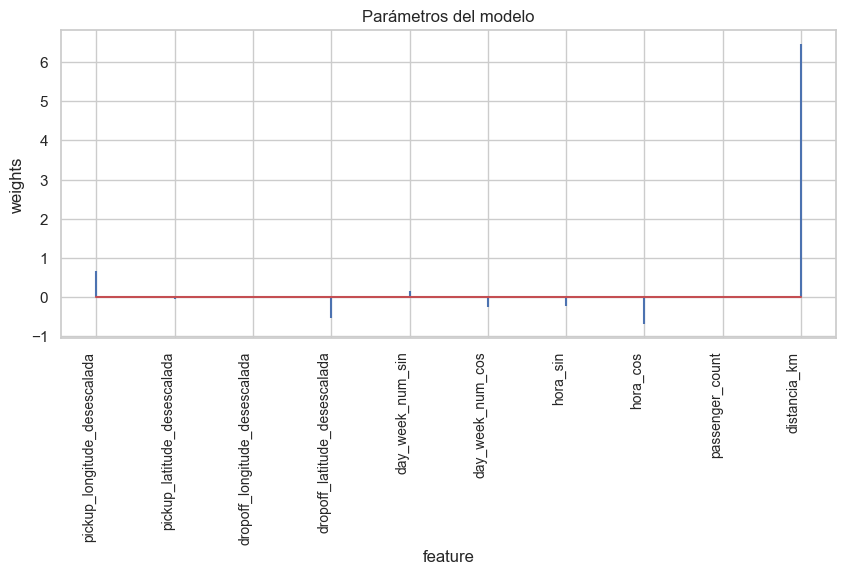

In [ ]:
# Coeficientes del modelo

df_coeficientes = pd.DataFrame({'predictor': X_train_scaled.columns, 'coef': df_coeficientes.coef})

fig, ax = plt.subplots(figsize=(10, 4))
ax.stem(df_coeficientes.predictor, df_coeficientes.coef, markerfmt=' ')
plt.xticks(rotation=90, ha='right', size=10)
ax.set_xlabel('feature')
ax.set_ylabel('weights')
ax.set_title('Parámetros del modelo')
plt.show()

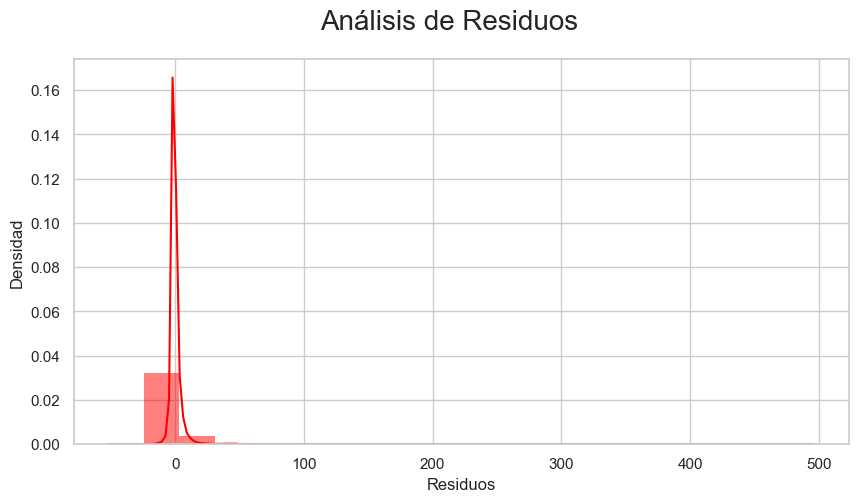

In [ ]:
# Análisis de Residuos
fig = plt.figure(figsize=(10,5))

sns.histplot((y_test - y_pred_test_rl), color="red", kde=True, stat="density", linewidth=0, bins=20)
fig.suptitle('Análisis de Residuos', fontsize = 20)
plt.xlabel('Residuos')
plt.ylabel('Densidad')
plt.show()

Vemos que la mayoria de los residuos estan cerca del 0, por lo que no habria tanta diferencia entre los valores observados y los valores predichos por el modelo.

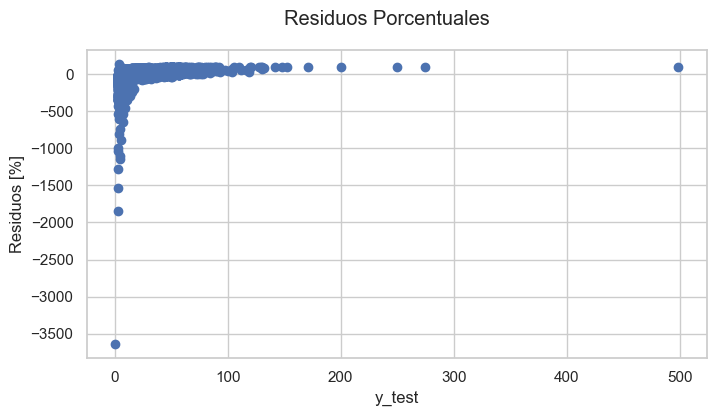

In [ ]:
fig = plt.figure(figsize=(8,4))
fig.suptitle('Residuos Porcentuales')
plt.xlabel('y_test')
plt.ylabel('Residuos [%]')
plt.scatter(y_test,100*(y_test-y_pred_test_rl)/y_test)
plt.show()

# Gradiente Descendente

In [ ]:
def gradient_descent(X_train, y_train, X_val, y_val, lr=0.01, epochs=100):
    """
    shapes:
        X_train = nxm
        y_train = nx1
        X_val = pxm
        y_test = px1
        W = mx1
    """
    n = X_train.shape[0]
    m = X_train.shape[1]

    o = X_val.shape[0]

    # Poner columna de unos a las matrices X
    X_train = np.hstack((np.ones((n, 1)), X_train))
    X_val = np.hstack((np.ones((o, 1)), X_val))


    # Inicializar pesos aleatorios
    W = np.random.randn(m+1).reshape(m+1, 1)

    train_errors = []  # Para almacenar el error de entrenamiento en cada época
    test_errors = []   # Para almacenar el error de prueba en cada época

    for _ in range(epochs):
        # Calcular predicción y error de entrenamiento
        prediction_train = np.matmul(X_train, W)
        error_train = y_train - prediction_train
        #print(error_train)
        train_mse = np.mean(error_train ** 2)
        train_errors.append(train_mse)

        # Calcular predicción y error de prueba
        prediction_test = np.matmul(X_val, W)
        error_test = y_val - prediction_test
        test_mse = np.mean(error_test ** 2)
        test_errors.append(test_mse)

        # Calcular el gradiente y actualizar pesos
        grad_sum = np.sum(error_train * X_train, axis=0)
        grad_mul = -2/n * grad_sum  # 1xm
        gradient = np.transpose(grad_mul).reshape(-1, 1)  # mx1

        W = W - (lr * gradient)

    # Graficar errores de entrenamiento y prueba
    # Definir una figura
    plt.figure(figsize=(12, 6))
    # Plotear errores de entrenamiento
    plt.plot(train_errors, label='Error de entrenamiento')
    # Plotear errores de prueba
    plt.plot(test_errors, label='Error de validación')
    # Poner labels en los ejes
    plt.xlabel('Época')
    plt.ylabel('Error cuadrático medio')
    # Activar la leyenda
    plt.legend()
    # Poner titulo
    plt.title('Error de entrenamiento y validación vs iteraciones (GD)')
    # Terminar y mostrar gráfico
    plt.show()

    return W

In [ ]:
def stochastic_gradient_descent(X_train, y_train, X_test, y_test, lr=0.01, epochs=100):

    n = X_train.shape[0]
    m = X_train.shape[1]

    X_train = np.hstack((np.ones((n, 1)), X_train))
    X_test = np.hstack((np.ones((X_test.shape[0], 1)), X_test))

    W = np.random.randn(m + 1).reshape(-1, 1)

    train_errors = []
    test_errors = []

    for i in range(epochs):
        # Permutación aleatoria de los datos
        permutation = np.random.permutation(n)
        X_train = X_train[permutation]
        y_train = y_train[permutation]

        for j in range(n):
            # Obtener una muestra aleatoria de un solo dato para hacer SGD
            x_sample = X_train[j]
            y_sample = y_train[j][0]

            prediction = np.matmul(x_sample, W)
            error = y_sample - prediction
            train_mse = error ** 2
            train_errors.append(train_mse)

            prediction_test = np.matmul(X_test, W)
            error_test = y_test - prediction_test
            test_mse = np.mean(error_test ** 2)
            test_errors.append(test_mse)

            gradient = -2 * error * x_sample.T.reshape(-1, 1)

            W = W - (lr * gradient)



    plt.figure(figsize=(12, 6))
    plt.plot(train_errors, label='Error de entrenamiento')
    plt.plot(test_errors, label='Error de prueba')
    plt.xlabel('Iteración')
    plt.ylabel('Error cuadrático medio')
    plt.legend()
    plt.title('Error de entrenamiento y prueba vs iteraciones (SGD)')
    plt.show()

    return W

In [ ]:
def mini_batch_gradient_descent(X_train, y_train, X_test, y_test, lr=0.01, epochs=100, batch_size=11):
    n = X_train.shape[0]
    m = X_train.shape[1]

    X_train = np.hstack((np.ones((n, 1)), X_train))
    X_test = np.hstack((np.ones((X_test.shape[0], 1)), X_test))

    W = np.random.randn(m + 1).reshape(-1, 1)

    train_errors = []
    test_errors = []

    for i in range(epochs):

        # Permutación aleatoria de los datos
        permutation = np.random.permutation(n)
        X_train = X_train[permutation]
        y_train = y_train[permutation]


        for j in range(0, n, batch_size):
            # Obtener un lote (mini-batch) de datos
            x_batch = X_train[j:j+batch_size, :]
            y_batch = y_train[j:j+batch_size].reshape(-1, 1)

            prediction = np.matmul(x_batch, W)
            error = y_batch - prediction
            train_mse = np.mean(error ** 2)
            train_errors.append(train_mse)

            gradient = -2 * np.matmul(x_batch.T, error) / batch_size

            W = W - (lr * gradient)

            prediction_test = np.matmul(X_test, W)
            error_test = y_test - prediction_test
            test_mse = np.mean(error_test ** 2)
            test_errors.append(test_mse)

    plt.figure(figsize=(12, 6))
    plt.plot(train_errors, label='Error de entrenamiento')
    plt.plot(test_errors, label='Error de prueba')
    plt.xlabel('Iteración')
    plt.ylabel('Error cuadrático medio')
    plt.legend()
    plt.title('Error de entrenamiento y prueba vs iteraciones (Mini-Batch GD)')
    plt.show()

    return W

In [ ]:
X_train_gd, X_val_gd, y_train_gd, y_val_gd = train_test_split(X_train_scaled, y_train, test_size=0.125, random_state=42)

In [ ]:
# Convertimos a arrays de numpy
X_train_gd = np.array(X_train_gd)
X_val_gd = np.array(X_val_gd)
y_train_gd = np.array(y_train_gd).reshape(-1, 1)
y_val_gd = np.array(y_val_gd).reshape(-1, 1)
X_test_scaled = np.array(X_test_scaled)
y_test = np.array(y_test).reshape(-1, 1)

In [ ]:
# Verificar shapes
print("Shapes después de conversión:")
print(f"X_train: {X_train_gd.shape}")
print(f"X_val: {X_val_gd.shape}")
print(f"y_train: {y_train_gd.shape}")
print(f"y_val: {y_val_gd.shape}")

Shapes después de conversión:
X_train: (138384, 10)
X_val: (19770, 10)
y_train: (138384, 1)
y_val: (19770, 1)


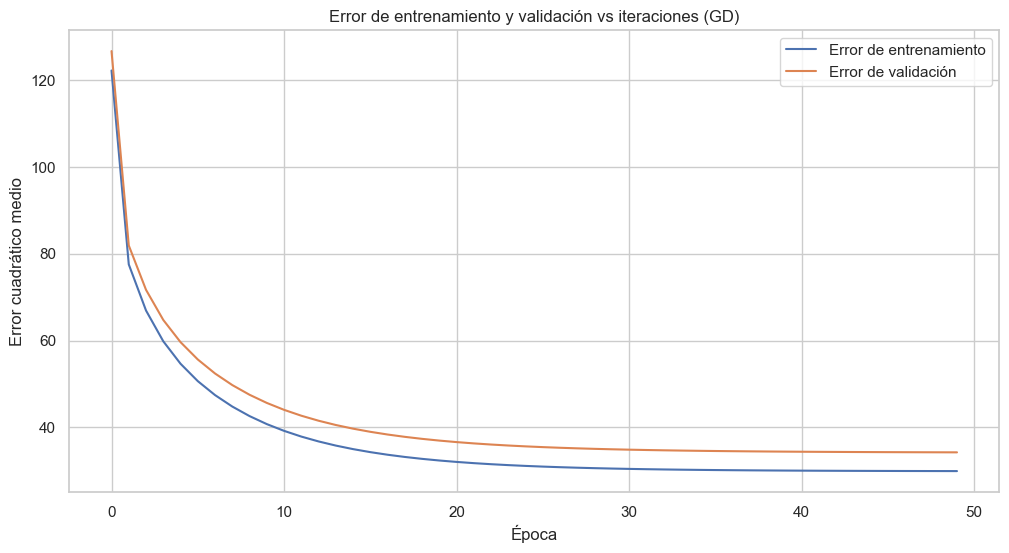

array([[10.3593958 ],
       [ 0.66253678],
       [-0.05433937],
       [ 0.03548012],
       [-0.55661467],
       [ 0.16375952],
       [-0.27955904],
       [-0.34646464],
       [-0.76201793],
       [ 0.16391222],
       [ 6.45720198]])

In [ ]:
gradient_descent(X_train_gd, y_train_gd, X_val_gd, y_val_gd, lr=0.1, epochs=50)

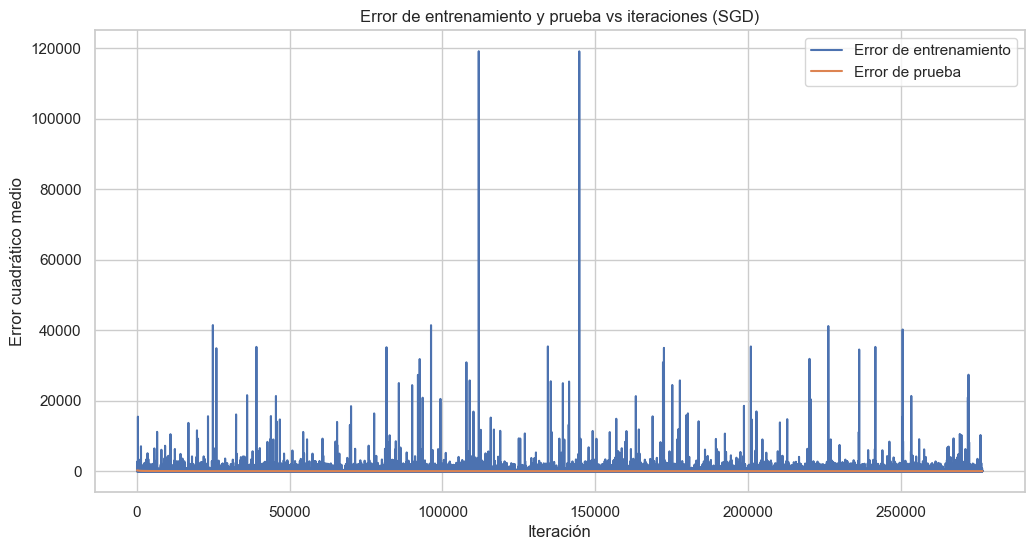

array([[ 1.06516596e+01],
       [ 5.94024213e-01],
       [ 6.28251355e-02],
       [-2.77603556e-02],
       [-4.51417260e-01],
       [ 1.24269527e-01],
       [-2.68939806e-01],
       [-1.33555504e-01],
       [-7.83705245e-01],
       [-7.02979941e-04],
       [ 6.48518680e+00]])

In [ ]:
stochastic_gradient_descent(X_train_gd, y_train_gd, X_val_gd, y_val_gd, lr=0.0001, epochs=2)

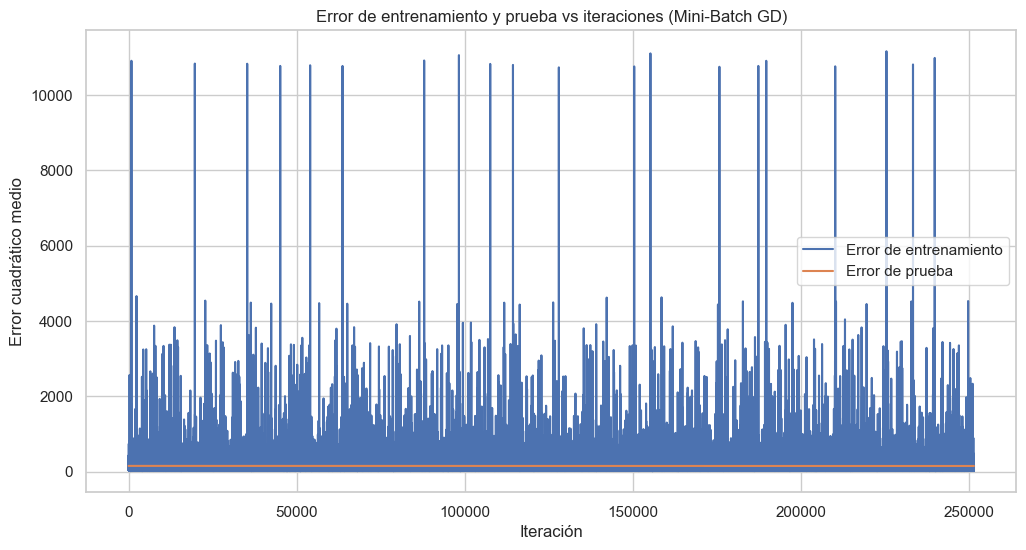

array([[-0.3535061 ],
       [ 0.08131148],
       [-1.02059029],
       [-0.38011109],
       [ 0.61104872],
       [-1.28681931],
       [-0.20244485],
       [-0.84063906],
       [ 1.3486105 ],
       [ 1.8543412 ],
       [ 0.56050875]])

In [ ]:
mini_batch_gradient_descent(X_train_gd, y_train_gd, X_val_gd, y_val_gd, lr=0.00000001, epochs=20)

# Regularizacion

### Lasso

In [ ]:
# Lasso con alpha=0.1
lasso = Lasso(alpha=0.1, max_iter=1000, random_state=42)
lasso.fit(X_train_scaled, y_train)

# Predicciones sobre el conjunto de entrenamiento
y_pred_train_lasso = lasso.predict(X_train_scaled)

# Métricas de entrenamiento
mse_train_lasso = mean_squared_error(y_train, y_pred_train_lasso)
rmse_train_lasso = math.sqrt(mse_train_lasso)
r2_train_lasso = r2_score(y_train, y_pred_train_lasso)

print("RESULTADOS DEL MODELO LASSO:")

print(f"\nMÉTRICAS EN ENTRENAMIENTO:")
print(f"  Error Cuadrático Medio (MSE): {mse_train_lasso:.3f}")
print(f"  Raíz del Error Cuadrático (RMSE): {rmse_train_lasso:.3f}")
print(f"  Coeficiente de Determinación (R²): {r2_train_lasso:.3f}")

RESULTADOS DEL MODELO LASSO:

MÉTRICAS EN ENTRENAMIENTO:
  Error Cuadrático Medio (MSE): 30.522
  Raíz del Error Cuadrático (RMSE): 5.525
  Coeficiente de Determinación (R²): 0.600


In [ ]:
# Predicciones sobre el conjunto de test
y_pred_test_lasso = lasso.predict(X_test_scaled)

# Métricas de test
mse_test_lasso = mean_squared_error(y_test, y_pred_test_lasso)
rmse_test_lasso = math.sqrt(mse_test_lasso)
r2_test_lasso = r2_score(y_test, y_pred_test_lasso)

print(f"\nMÉTRICAS EN TEST:")
print(f"  Error Cuadrático Medio (MSE): {mse_test_lasso:.3f}")
print(f"  Raíz del Error Cuadrático (RMSE): {rmse_test_lasso:.3f}")
print(f"  Coeficiente de Determinación (R²): {r2_test_lasso:.3f}")


MÉTRICAS EN TEST:
  Error Cuadrático Medio (MSE): 41.266
  Raíz del Error Cuadrático (RMSE): 6.424
  Coeficiente de Determinación (R²): 0.612


## Ridge

In [ ]:
# Ridge con alpha=0.1
ridge = Ridge(alpha=0.1, max_iter=1000, random_state=42)
ridge.fit(X_train_scaled, y_train)

# Predicciones sobre el conjunto de entrenamiento
y_pred_train_ridge = ridge.predict(X_train_scaled)

# Métricas de entrenamiento
mse_train_ridge = mean_squared_error(y_train, y_pred_train_ridge)
rmse_train_ridge = math.sqrt(mse_train_ridge)
r2_train_ridge = r2_score(y_train, y_pred_train_ridge)

print("RESULTADOS DEL MODELO RIDGE")

print(f"\nMÉTRICAS EN ENTRENAMIENTO:")
print(f"  Error Cuadrático Medio (MSE): {mse_train_ridge:.3f}")
print(f"  Raíz del Error Cuadrático (RMSE): {rmse_train_ridge:.3f}")
print(f"  Coeficiente de Determinación (R²): {r2_train_ridge:.3f}")

RESULTADOS DEL MODELO RIDGE

MÉTRICAS EN ENTRENAMIENTO:
  Error Cuadrático Medio (MSE): 30.416
  Raíz del Error Cuadrático (RMSE): 5.515
  Coeficiente de Determinación (R²): 0.601


In [ ]:
# Predicciones sobre el conjunto de test
y_pred_test_ridge = ridge.predict(X_test_scaled)

# Métricas de test
mse_test_ridge = mean_squared_error(y_test, y_pred_test_ridge)
rmse_test_ridge = math.sqrt(mse_test_ridge)
r2_test_ridge = r2_score(y_test, y_pred_test_ridge)

print(f"\nMÉTRICAS EN TEST:")
print(f"  Error Cuadrático Medio (MSE): {mse_test_ridge:.3f}")
print(f"  Raíz del Error Cuadrático (RMSE): {rmse_test_ridge:.3f}")
print(f"  Coeficiente de Determinación (R²): {r2_test_ridge:.3f}")


MÉTRICAS EN TEST:
  Error Cuadrático Medio (MSE): 41.222
  Raíz del Error Cuadrático (RMSE): 6.420
  Coeficiente de Determinación (R²): 0.612


In [ ]:
# Mostrar coeficientes
print("\nCoeficientes del modelo Ridge:")
print(ridge.coef_)
print(ridge.score(X_train_scaled, y_train))


Coeficientes del modelo Ridge:
[ 6.60253947e-01 -4.29351247e-02 -5.37443183e-03 -5.38759954e-01
  1.47707867e-01 -2.47609679e-01 -2.29623869e-01 -6.89062640e-01
  3.48552915e-02  6.46886245e+00]
0.601378534411856


## Elastic Net

In [ ]:
# Elastic Net con alpha=0.1 y l1_ratio=0.5
elasticnet = ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=1000, random_state=42)
elasticnet.fit(X_train_scaled, y_train)

# Predicciones sobre el conjunto de entrenamiento
y_pred_train_en = elasticnet.predict(X_train_scaled)

# Métricas de entrenamiento
mse_train_en = mean_squared_error(y_train, y_pred_train_en)
rmse_train_en = math.sqrt(mse_train_en)
r2_train_en = r2_score(y_train, y_pred_train_en)

print("RESULTADOS DEL MODELO Elastic Net")

print(f"\nMÉTRICAS EN ENTRENAMIENTO:")
print(f"  Error Cuadrático Medio (MSE): {mse_train_en:.3f}")
print(f"  Raíz del Error Cuadrático (RMSE): {rmse_train_en:.3f}")
print(f"  Coeficiente de Determinación (R²): {r2_train_en:.3f}")

RESULTADOS DEL MODELO Elastic Net

MÉTRICAS EN ENTRENAMIENTO:
  Error Cuadrático Medio (MSE): 30.593
  Raíz del Error Cuadrático (RMSE): 5.531
  Coeficiente de Determinación (R²): 0.599


In [ ]:
# Predicciones sobre el conjunto de test
y_pred_test_en = elasticnet.predict(X_test_scaled)

# Métricas de test
mse_test_en = mean_squared_error(y_test, y_pred_test_en)
rmse_test_en = math.sqrt(mse_test_en)
r2_test_en = r2_score(y_test, y_pred_test_en)

print(f"\nMÉTRICAS EN TEST:")
print(f"  Error Cuadrático Medio (MSE): {mse_test_en:.3f}")
print(f"  Raíz del Error Cuadrático (RMSE): {rmse_test_en:.3f}")
print(f"  Coeficiente de Determinación (R²): {r2_test_en:.3f}")


MÉTRICAS EN TEST:
  Error Cuadrático Medio (MSE): 41.370
  Raíz del Error Cuadrático (RMSE): 6.432
  Coeficiente de Determinación (R²): 0.611


# Comparacion modelos

In [ ]:
# Crear DataFrame de comparación
comparison_data = {
    'Modelo': ['Regresión Lineal', 'Lasso', 'Ridge', 'Elastic Net'],
    'MSE_Train': [mse_train_rl, mse_train_lasso, mse_train_ridge, mse_train_en],
    'RMSE_Train': [rmse_train_rl, rmse_train_lasso, rmse_train_ridge, rmse_train_en],
    'R2_Train': [r2_train_rl, r2_train_lasso, r2_train_ridge, r2_train_en],
    'MSE_Test': [mse_test_rl, mse_test_lasso, mse_test_ridge, mse_test_en],
    'RMSE_Test': [rmse_test_rl, rmse_test_lasso, rmse_test_ridge, rmse_test_en],
    'R2_Test': [r2_test_rl, r2_test_lasso, r2_test_ridge, r2_test_en]
}

comparison_df = pd.DataFrame(comparison_data)
comparison_df = comparison_df.round(4)

print("TABLA COMPARATIVA DE MODELOS")
print(comparison_df.to_string(index=False))

TABLA COMPARATIVA DE MODELOS
          Modelo  MSE_Train  RMSE_Train  R2_Train  MSE_Test  RMSE_Test  R2_Test
Regresión Lineal    30.4161      5.5151    0.6014   41.2220     6.4204   0.6122
           Lasso    30.5221      5.5247    0.6000   41.2659     6.4239   0.6118
           Ridge    30.4161      5.5151    0.6014   41.2220     6.4204   0.6122
     Elastic Net    30.5931      5.5311    0.5991   41.3697     6.4319   0.6108


- La regresion lineal y Ridge obtuvieron las mismas metricas, tanto en el conjunto de entrenamiento como en el de testeo.
- A su vez, fueron los que obtuvieron valores mas bajos de MSE.
- El error promedio se encuentra entre el rango [5.5151, 5.5311] en entrenamiento y [6.4204, 6.4319] en pruebas.
- Todos los modelos explican aproximadamente el 60% de la varianza.

## Conclusion
Como la Regresion Lineal y Ridge obtuvieron los mismos puntajes (y tambien los mejores), concluimos que una regularizacion no aporta mejoras y se deberia usar la Regresion Lineal por simplicidad.